# Spatial Correctness and Richness vs avg_rad (Species-wise and District-wise)

This notebook is fully richness-based and does not use individualCount.

Scope:
- Spatial correctness using 5 km grid-based thinning
- Richness summaries before and after thinning
- District-wise and species-wise richness relationships with avg_rad
- Visualizations focused on richness patterns after thinning

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="paper")
pd.set_option("display.max_columns", 80)
plt.rcParams["figure.dpi"] = 120
RANDOM_SEED = 42

## 1. Load dataset (bird identity + location + avg_rad only)

In [24]:
candidate_paths = [
    Path("file6.csv"),
    Path("../file6.csv"),
    Path("../../file6.csv"),
    Path("final5.csv"),
    Path("../final5.csv"),
    Path("../../final5.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find file6.csv or final5.csv from this notebook location.")

raw = pd.read_csv(data_path, low_memory=False)
required_cols = [
    "stateProvince",
    "verbatimScientificName",
    "decimalLatitude",
    "decimalLongitude",
    "eventDate",
    "avg_rad",
]
missing = [c for c in required_cols if c not in raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = raw[required_cols].copy()
df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")
for c in ["decimalLatitude", "decimalLongitude", "avg_rad"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["stateProvince"] = df["stateProvince"].astype(str).str.strip()
df["verbatimScientificName"] = df["verbatimScientificName"].astype(str).str.strip()
df = df.dropna(subset=["stateProvince", "verbatimScientificName", "decimalLatitude", "decimalLongitude", "eventDate", "avg_rad"])

print(f"Using: {data_path.resolve()}")
print(f"Rows after cleaning: {len(df):,}")
print(f"Districts (stateProvince): {df['stateProvince'].nunique():,}")
print(f"Species: {df['verbatimScientificName'].nunique():,}")

Using: /home/ekeke/Projects/DataScience/bird_diversity_project/file6.csv
Rows after cleaning: 1,552,048
Districts (stateProvince): 25
Species: 429


## 2. Spatial correctness: 5 km grid-based thinning

## How thinning works (simple version)

Goal: if the same species is recorded many times in the same 5 km cell, keep only one row for that species in that cell.

Steps:
1. Put every record on a 5 km x 5 km grid within each district (stateProvince).
2. Build a thinning key as stateProvince + cell + species name.
3. Assign a random number and keep one row per thinning key.

Result: one cell can still contain many species, but each species appears at most once in that cell after thinning.

In [25]:
def add_5km_grid(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    lon0 = float(out["decimalLongitude"].median())
    lat0 = float(out["decimalLatitude"].median())
    lat_rad = np.radians(out["decimalLatitude"].to_numpy())
    out["x_km"] = (out["decimalLongitude"].to_numpy() - lon0) * 111.320 * np.cos(lat_rad)
    out["y_km"] = (out["decimalLatitude"].to_numpy() - lat0) * 110.574
    out["grid_x"] = np.floor(out["x_km"] / 5.0).astype(int)
    out["grid_y"] = np.floor(out["y_km"] / 5.0).astype(int)
    out["cell_id"] = out["stateProvince"].astype(str) + "|" + out["grid_x"].astype(str) + "_" + out["grid_y"].astype(str)
    return out

def thin_per_species_cell(frame: pd.DataFrame, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    work = frame.copy()
    work["_thin_key"] = (work["stateProvince"].astype(str) + "|" + work["grid_x"].astype(str) + "_" + work["grid_y"].astype(str) + "|" + work["verbatimScientificName"].astype(str))
    work["_rand"] = rng.random(len(work))
    return work.sort_values("_rand").groupby("_thin_key", as_index=False).head(1).drop(columns=["_thin_key", "_rand"])

df_grid = add_5km_grid(df)
df_thin = thin_per_species_cell(df_grid, seed=RANDOM_SEED)

print(f"Records before thinning: {len(df_grid):,}")
print(f"Records after thinning:  {len(df_thin):,}")
print(f"Retained fraction:       {len(df_thin)/len(df_grid):.2%}")

Records before thinning: 1,552,048
Records after thinning:  95,608
Retained fraction:       6.16%


## 3. District-wise richness and retention

In [26]:
district_full = df_grid.groupby("stateProvince", as_index=False).agg(n_records_full=("verbatimScientificName", "size"), species_richness_full=("verbatimScientificName", "nunique"), avg_rad_mean_full=("avg_rad", "mean"))
district_thin = df_thin.groupby("stateProvince", as_index=False).agg(n_records_thin=("verbatimScientificName", "size"), species_richness_thin=("verbatimScientificName", "nunique"), avg_rad_mean_thin=("avg_rad", "mean"))
district_metrics = district_full.merge(district_thin, on="stateProvince", how="outer").fillna(0)
for c in ["n_records_full", "species_richness_full", "n_records_thin", "species_richness_thin"]:
    district_metrics[c] = district_metrics[c].astype(int)
district_metrics["retention_pct"] = np.where(district_metrics["n_records_full"] > 0, 100 * district_metrics["n_records_thin"] / district_metrics["n_records_full"], np.nan)
district_metrics["richness_retention_pct"] = np.where(district_metrics["species_richness_full"] > 0, 100 * district_metrics["species_richness_thin"] / district_metrics["species_richness_full"], np.nan)
district_metrics = district_metrics.sort_values("species_richness_thin", ascending=False)
district_metrics.head(30)

,stateProvince,n_records_full,species_richness_full,avg_rad_mean_full,n_records_thin,species_richness_thin,avg_rad_mean_thin,retention_pct,richness_retention_pct
7,Hambantota,161216,329,0.627058,7205,329,0.892937,4.469159,100.0
14,Mannar,63446,304,0.754670,4037,304,0.733272,6.362891,100.0
6,Gampaha,179526,303,9.000751,4741,303,4.728292,2.640843,100.0
22,Ratnapura,116834,301,0.518911,6866,301,0.719774,5.876714,100.0
16,Matara,123577,299,2.023344,3930,299,1.148045,3.180203,100.0
21,Puttalam,44845,283,1.089537,5984,283,1.083852,13.343740,100.0
17,Monaragala,68731,281,0.505858,5985,281,0.544136,8.707861,100.0
4,Colombo,289337,280,11.073666,3306,280,8.013272,1.142612,100.0
15,Matale,52327,268,0.625425,4385,268,0.618676,8.379995,100.0
5,Galle,59162,259,2.397487,3689,259,1.356353,6.235421,100.0


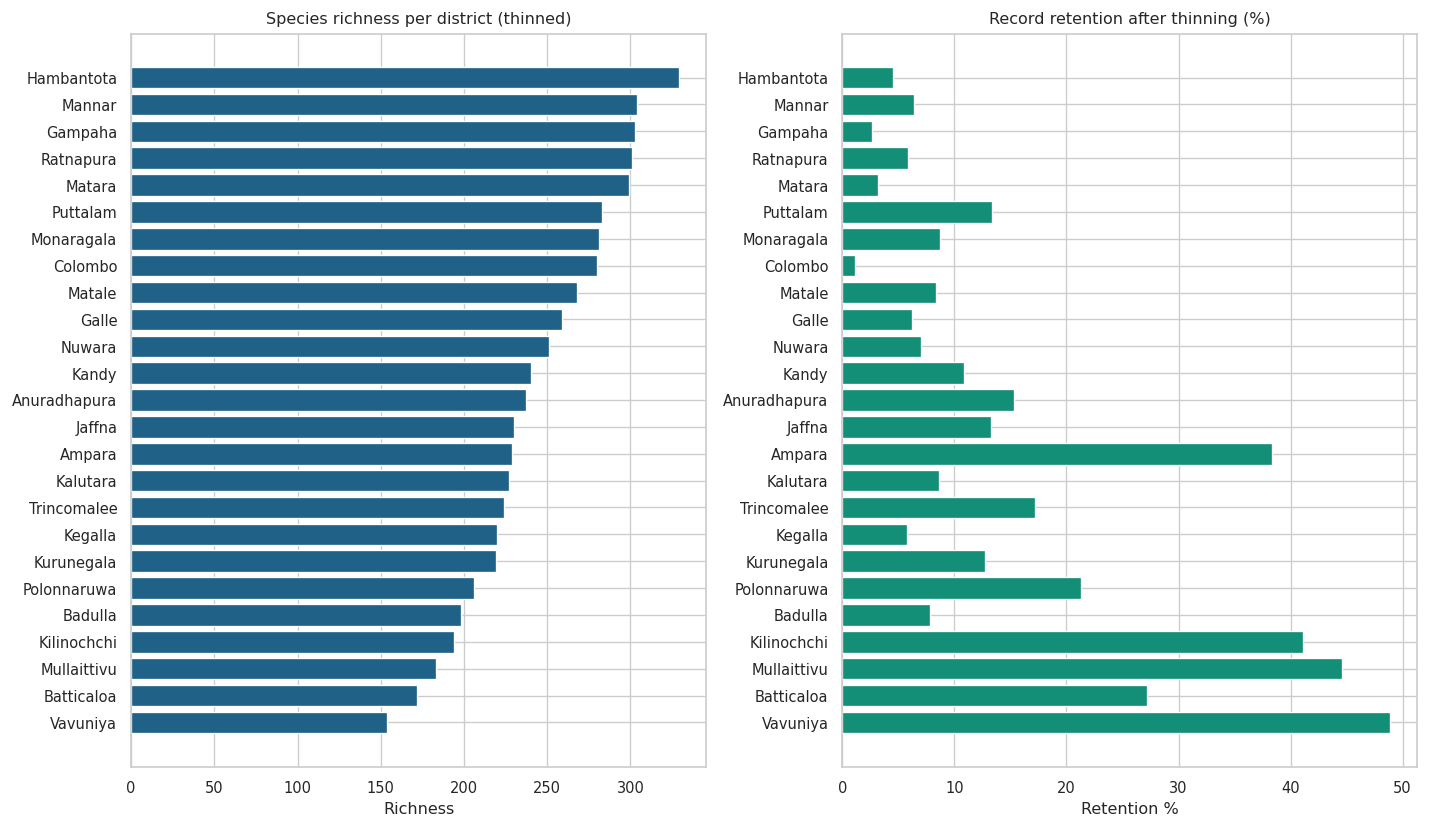

In [27]:
plot_df = district_metrics.sort_values("species_richness_thin", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(12, max(5, 0.28 * len(plot_df))))
axes[0].barh(plot_df["stateProvince"], plot_df["species_richness_thin"], color="#1f6187")
axes[0].set_title("Species richness per district (thinned)")
axes[0].set_xlabel("Richness")
axes[1].barh(plot_df["stateProvince"], plot_df["retention_pct"], color="#148f77")
axes[1].set_title("Record retention after thinning (%)")
axes[1].set_xlabel("Retention %")
plt.tight_layout()
plt.show()

## 4. District-wise richness vs avg_rad correlation (cell-based)

In [28]:
# Build 5 km cell summaries from thinned records
cell_summary = (
    df_thin.groupby(["stateProvince", "cell_id"], as_index=False)
    .agg(
        species_richness=("verbatimScientificName", "nunique"),
        mean_avg_rad=("avg_rad", "mean"),
    )
)

MIN_CELLS_DISTRICT = 8
district_corr_rows = []
for d, sub in cell_summary.groupby("stateProvince"):
    s = sub[["species_richness", "mean_avg_rad"]].dropna()
    if len(s) < MIN_CELLS_DISTRICT:
        continue
    r_s, p_s = stats.spearmanr(s["species_richness"], s["mean_avg_rad"], nan_policy="omit")
    district_corr_rows.append(
        {
            "stateProvince": d,
            "n_cells": len(s),
            "spearman_r": r_s,
            "spearman_p": p_s,
        }
    )

district_corr = pd.DataFrame(district_corr_rows).sort_values("spearman_r", ascending=False)
print(f"Districts analyzed (cells >= {MIN_CELLS_DISTRICT}): {len(district_corr)}")
district_corr.head(30)

Districts analyzed (cells >= 8): 25


,stateProvince,n_cells,spearman_r,spearman_p
6,Gampaha,68,0.531731,0.000003
4,Colombo,39,0.496988,0.001289
14,Mannar,50,0.335751,0.017139
10,Kandy,71,0.332319,0.004634
2,Badulla,73,0.273391,0.019268
5,Galle,70,0.272867,0.022288
13,Kurunegala,131,0.263360,0.002372
0,Ampara,64,0.178339,0.158562
1,Anuradhapura,124,0.176505,0.049879
3,Batticaloa,37,0.151427,0.370971


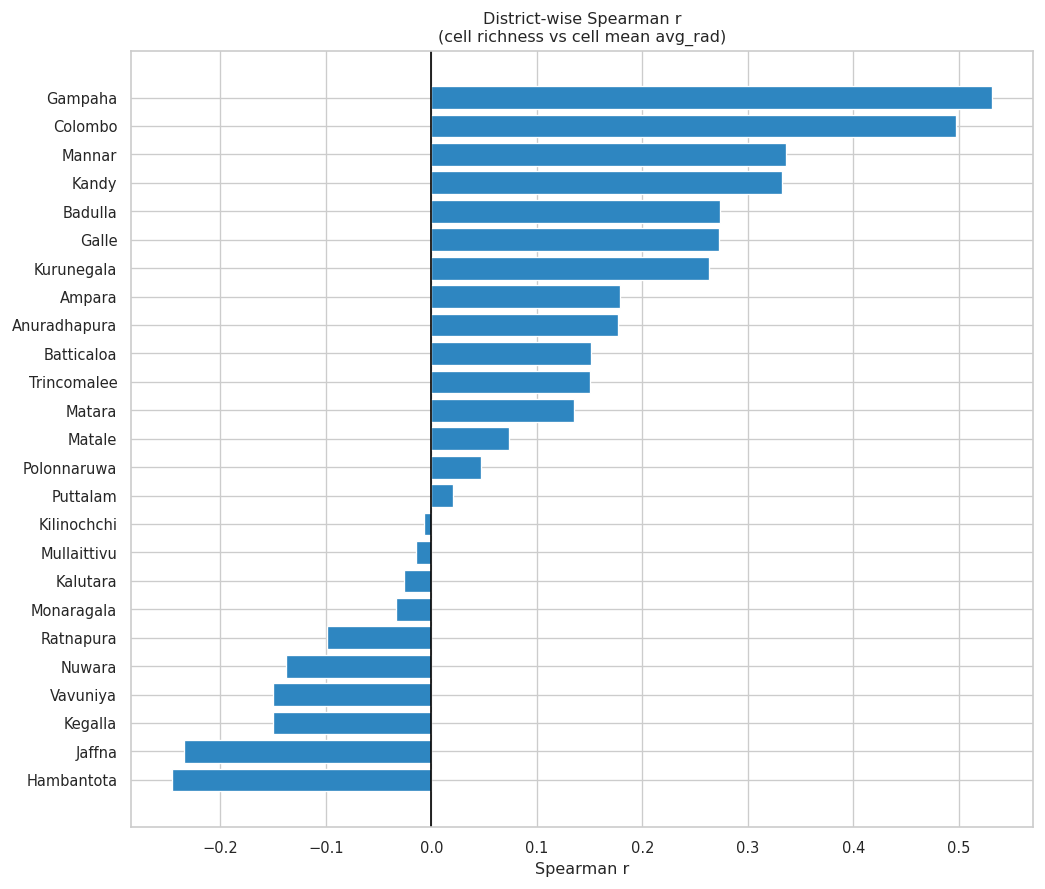

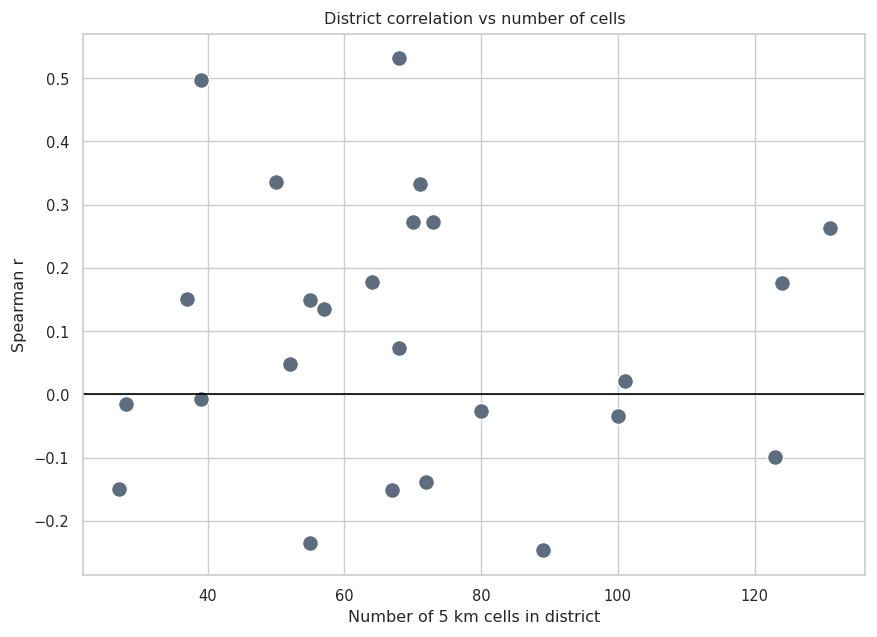

In [29]:
# District-wise visualization of richness-vs-avg_rad correlations
if len(district_corr):
    dc = district_corr.sort_values("spearman_r", ascending=True).copy()

    plt.figure(figsize=(8.8, max(5, 0.3 * len(dc))))
    plt.barh(dc["stateProvince"], dc["spearman_r"], color="#2e86c1")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("District-wise Spearman r\n(cell richness vs cell mean avg_rad)")
    plt.xlabel("Spearman r")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7.4, 5.4))
    sns.scatterplot(
        data=district_corr,
        x="n_cells",
        y="spearman_r",
        s=90,
        color="#5d6d7e",
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.title("District correlation vs number of cells")
    plt.xlabel("Number of 5 km cells in district")
    plt.ylabel("Spearman r")
    plt.tight_layout()
    plt.show()
else:
    print("No district richness-correlation results to plot.")

## 5. Species-wise richness footprint vs avg_rad

In [30]:
# Species footprint metrics from thinned table
species_summary = (
    df_thin.groupby("verbatimScientificName", as_index=False)
    .agg(
        n_cells_occupied=("cell_id", "nunique"),
        n_districts_occupied=("stateProvince", "nunique"),
        mean_avg_rad=("avg_rad", "mean"),
    )
)

MIN_CELLS_SPECIES = 5
species_summary = species_summary[species_summary["n_cells_occupied"] >= MIN_CELLS_SPECIES].copy()

r_species_cells, p_species_cells = stats.spearmanr(
    species_summary["n_cells_occupied"],
    species_summary["mean_avg_rad"],
    nan_policy="omit",
)
r_species_districts, p_species_districts = stats.spearmanr(
    species_summary["n_districts_occupied"],
    species_summary["mean_avg_rad"],
    nan_policy="omit",
)

print(f"Species retained (cells >= {MIN_CELLS_SPECIES}): {len(species_summary)}")
print(f"Spearman (n_cells_occupied vs mean_avg_rad): r={r_species_cells:.3f}, p={p_species_cells:.3g}")
print(f"Spearman (n_districts_occupied vs mean_avg_rad): r={r_species_districts:.3f}, p={p_species_districts:.3g}")
species_summary.sort_values("n_cells_occupied", ascending=False).head(30)

Species retained (cells >= 5): 357
Spearman (n_cells_occupied vs mean_avg_rad): r=0.050, p=0.351
Spearman (n_districts_occupied vs mean_avg_rad): r=0.203, p=0.000113


,verbatimScientificName,n_cells_occupied,n_districts_occupied,mean_avg_rad
367,Spilopelia chinensis,1340,25,1.182264
350,Pycnonotus cafer,1259,25,1.203700
200,Halcyon smyrnensis,1212,25,1.224399
1,Acridotheres tristis,1208,25,1.369332
48,Argya affinis,1057,25,1.363087
343,Psilopogon zeylanicus,1042,25,1.322106
289,Orthotomus sutorius,1018,25,1.364845
201,Haliastur indus,993,25,1.341673
288,Oriolus xanthornus,992,25,1.239555
347,Psittacula krameri,989,25,1.393382


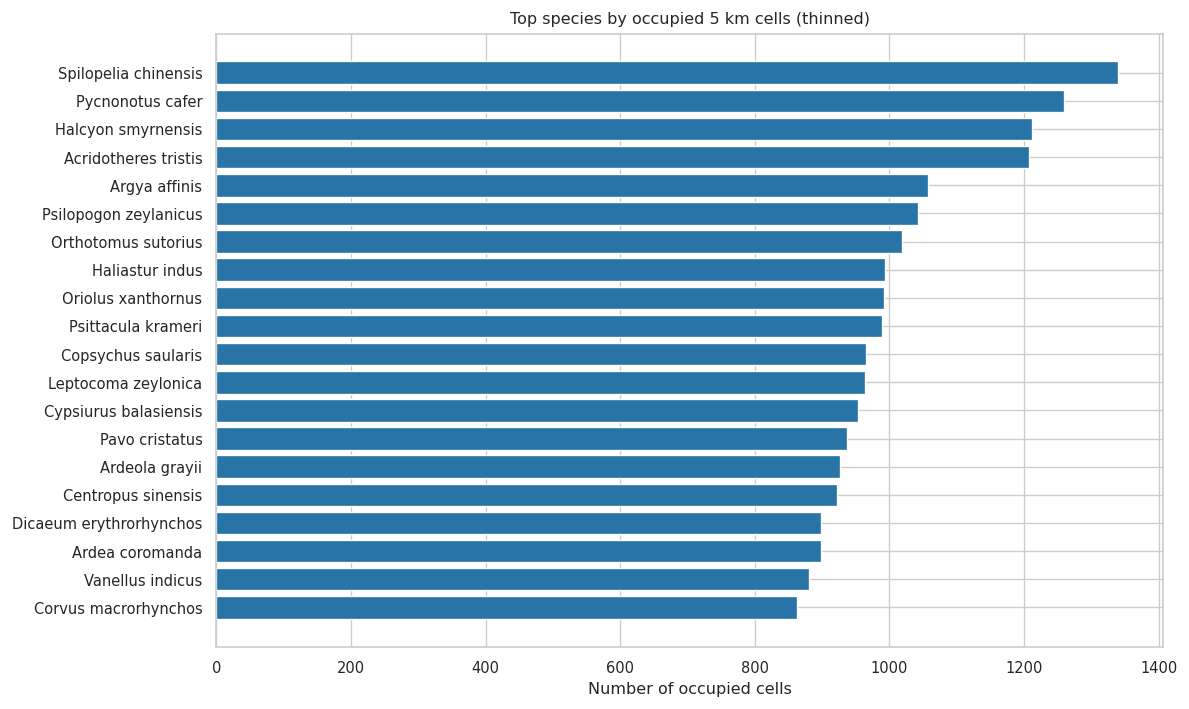

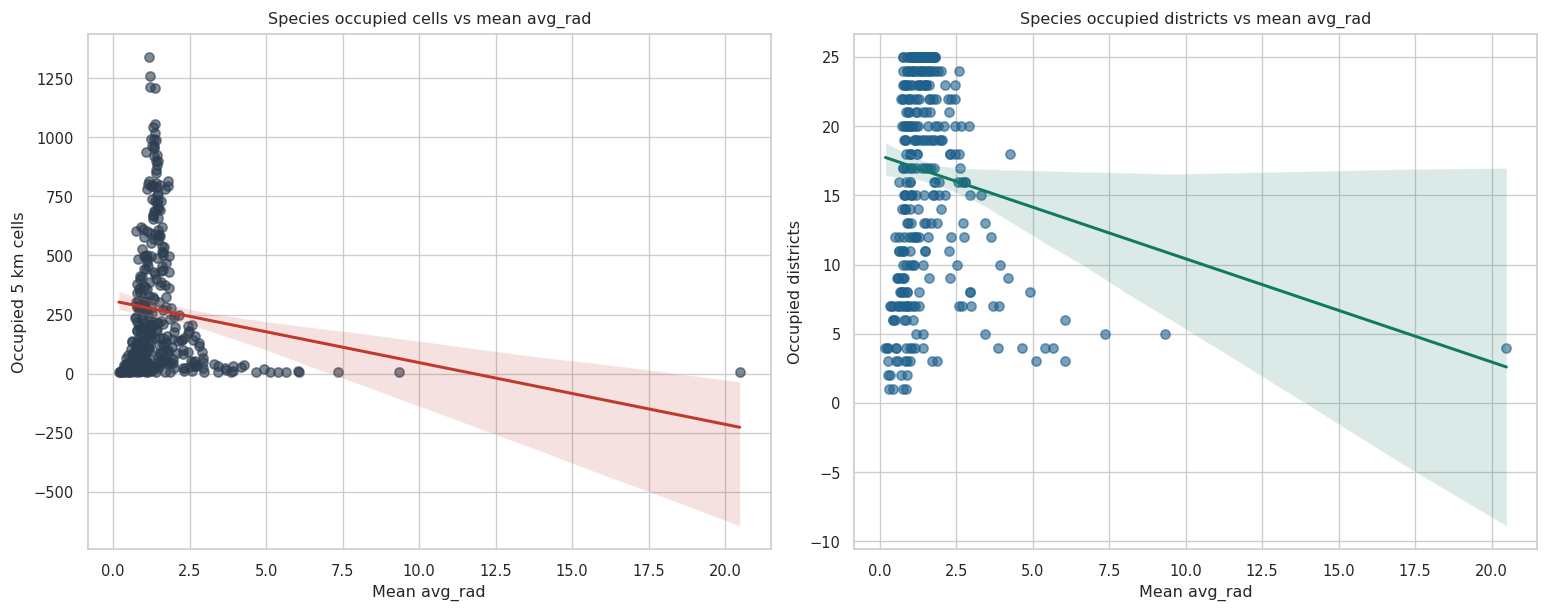

In [31]:
# Species-wise richness footprint visualizations
if len(species_summary):
    top_species = species_summary.nlargest(20, "n_cells_occupied").sort_values("n_cells_occupied", ascending=True)

    plt.figure(figsize=(10, max(6, 0.3 * len(top_species))))
    plt.barh(top_species["verbatimScientificName"], top_species["n_cells_occupied"], color="#2874a6")
    plt.title("Top species by occupied 5 km cells (thinned)")
    plt.xlabel("Number of occupied cells")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
    sns.regplot(
        data=species_summary,
        x="mean_avg_rad",
        y="n_cells_occupied",
        scatter_kws={"s": 30, "alpha": 0.6, "color": "#2c3e50"},
        line_kws={"color": "#c0392b"},
        ax=axes[0],
    )
    axes[0].set_title("Species occupied cells vs mean avg_rad")
    axes[0].set_xlabel("Mean avg_rad")
    axes[0].set_ylabel("Occupied 5 km cells")

    sns.regplot(
        data=species_summary,
        x="mean_avg_rad",
        y="n_districts_occupied",
        scatter_kws={"s": 30, "alpha": 0.6, "color": "#1f618d"},
        line_kws={"color": "#117864"},
        ax=axes[1],
    )
    axes[1].set_title("Species occupied districts vs mean avg_rad")
    axes[1].set_xlabel("Mean avg_rad")
    axes[1].set_ylabel("Occupied districts")

    plt.tight_layout()
    plt.show()
else:
    print("No species summary to plot.")

## 6. Overall richness vs avg_rad (district and grid-cell views)

In [32]:
district_richness_rad = (
    df_thin.groupby("stateProvince", as_index=False)
    .agg(
        species_richness=("verbatimScientificName", "nunique"),
        mean_avg_rad=("avg_rad", "mean"),
        n_thinned_rows=("verbatimScientificName", "size"),
    )
)

r_dist, p_dist = stats.spearmanr(
    district_richness_rad["species_richness"],
    district_richness_rad["mean_avg_rad"],
    nan_policy="omit",
)
print(f"District-level richness vs avg_rad (Spearman): r={r_dist:.3f}, p={p_dist:.3g}")
district_richness_rad.sort_values("species_richness", ascending=False).head(30)

grid_summary = (
    df_thin.groupby("cell_id", as_index=False)
    .agg(
        species_richness=("verbatimScientificName", "nunique"),
        mean_avg_rad=("avg_rad", "mean"),
    )
)
r_grid, p_grid = stats.spearmanr(
    grid_summary["species_richness"],
    grid_summary["mean_avg_rad"],
    nan_policy="omit",
)
print(f"Grid-cell richness vs avg_rad (Spearman): r={r_grid:.3f}, p={p_grid:.3g}")
print(f"Grid cells: {len(grid_summary):,}")

District-level richness vs avg_rad (Spearman): r=0.155, p=0.458
Grid-cell richness vs avg_rad (Spearman): r=0.106, p=8.57e-06
Grid cells: 1,740


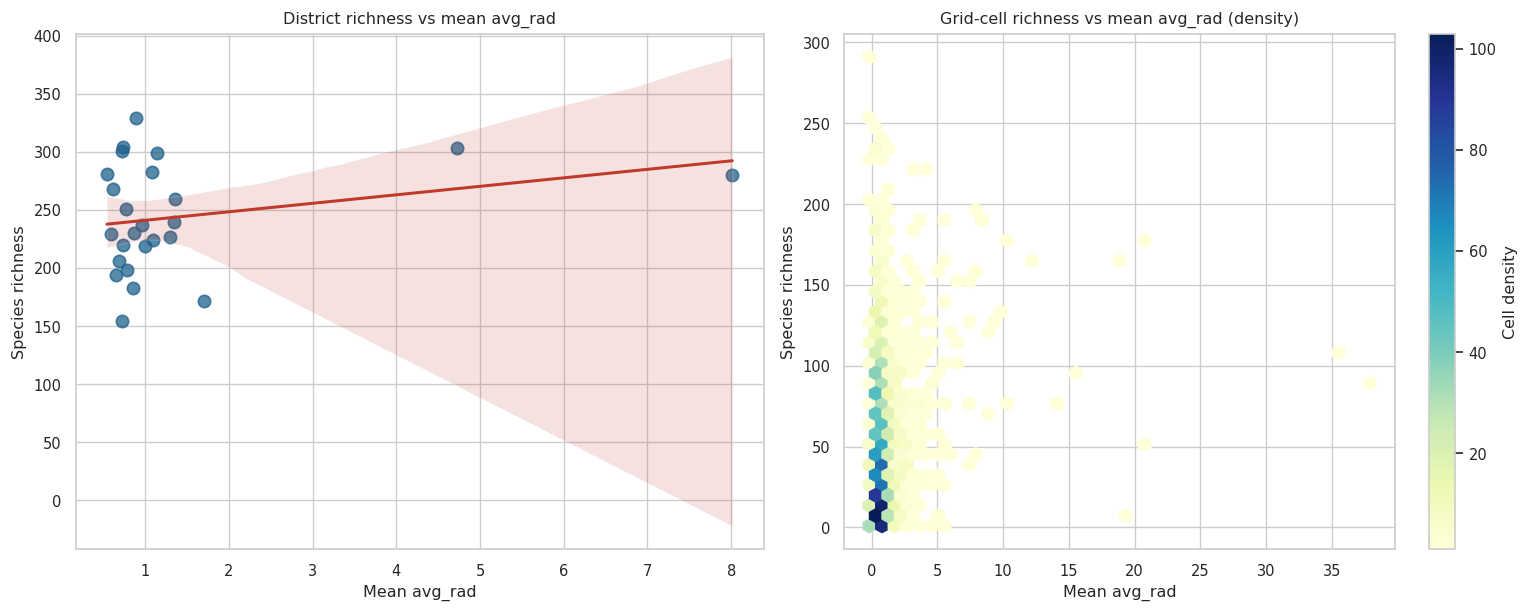

In [33]:
# Overall richness-vs-avg_rad visualizations
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

sns.regplot(
    data=district_richness_rad,
    x="mean_avg_rad",
    y="species_richness",
    scatter_kws={"s": 55, "alpha": 0.75, "color": "#1f618d"},
    line_kws={"color": "#c0392b"},
    ax=axes[0],
)
axes[0].set_title("District richness vs mean avg_rad")
axes[0].set_xlabel("Mean avg_rad")
axes[0].set_ylabel("Species richness")

hb = axes[1].hexbin(
    grid_summary["mean_avg_rad"],
    grid_summary["species_richness"],
    gridsize=40,
    cmap="YlGnBu",
    mincnt=1,
)
axes[1].set_title("Grid-cell richness vs mean avg_rad (density)")
axes[1].set_xlabel("Mean avg_rad")
axes[1].set_ylabel("Species richness")
cb = fig.colorbar(hb, ax=axes[1])
cb.set_label("Cell density")

plt.tight_layout()
plt.show()

## 7. Effort-bias fix via equal-cell rarefaction (district comparison)

This section controls for unequal reporting intensity by giving every district the same number of 5 km cells.

Method:
- Use thinned 5 km cells from cell_summary.
- Let MIN_CELLS_COMMON be the smallest number of cells among districts.
- For each iteration, sample exactly MIN_CELLS_COMMON cells per district (without replacement).
- Compute district mean cell richness on that equal-sized sample.
- Repeat many times and summarize median and 95% interval per district.

In [34]:
# Equal-cell rarefaction by district
N_ITER = 300
rng = np.random.default_rng(RANDOM_SEED)

cells_per_district = cell_summary.groupby("stateProvince").size().sort_values()
MIN_CELLS_COMMON = int(cells_per_district.min())
print(f"Minimum cells across districts (common sample size): {MIN_CELLS_COMMON}")
print(f"Rarefaction iterations: {N_ITER}")

by_district_cells = {
    d: sub[["cell_id", "species_richness", "mean_avg_rad"]].copy().reset_index(drop=True)
    for d, sub in cell_summary.groupby("stateProvince")
}

rare_rows = []
for i in range(N_ITER):
    for d, sub in by_district_cells.items():
        idx = rng.choice(len(sub), size=MIN_CELLS_COMMON, replace=False)
        sample = sub.iloc[idx]
        rare_rows.append(
            {
                "iter": i,
                "stateProvince": d,
                "mean_cell_richness_rarefied": float(sample["species_richness"].mean()),
                "mean_avg_rad_rarefied": float(sample["mean_avg_rad"].mean()),
            }
        )

rarefied_long = pd.DataFrame(rare_rows)
rarefied_summary = (
    rarefied_long.groupby("stateProvince", as_index=False)
    .agg(
        mean_cell_richness_median=("mean_cell_richness_rarefied", "median"),
        mean_cell_richness_q025=("mean_cell_richness_rarefied", lambda x: np.quantile(x, 0.025)),
        mean_cell_richness_q975=("mean_cell_richness_rarefied", lambda x: np.quantile(x, 0.975)),
        mean_avg_rad_median=("mean_avg_rad_rarefied", "median"),
    )
    .sort_values("mean_cell_richness_median", ascending=False)
)

r_rare, p_rare = stats.spearmanr(
    rarefied_summary["mean_cell_richness_median"],
    rarefied_summary["mean_avg_rad_median"],
    nan_policy="omit",
)
print(f"Rarefied district richness vs avg_rad (Spearman): r={r_rare:.3f}, p={p_rare:.3g}")
rarefied_summary.head(30)

Minimum cells across districts (common sample size): 27
Rarefaction iterations: 300
Rarefied district richness vs avg_rad (Spearman): r=0.080, p=0.704


,stateProvince,mean_cell_richness_median,mean_cell_richness_q025,mean_cell_richness_q975,mean_avg_rad_median
4,Colombo,84.925926,73.050926,94.264815,6.792754
14,Mannar,81.611111,66.119444,99.412963,0.596284
7,Hambantota,80.814815,58.752778,100.184259,0.887082
6,Gampaha,70.185185,56.887037,82.374074,3.471978
16,Matara,68.314815,56.577778,81.633333,0.991254
15,Matale,64.833333,52.054630,79.381481,0.612301
17,Monaragala,60.388889,42.057407,82.084259,0.551072
10,Kandy,59.407407,46.072222,71.525926,0.861305
8,Jaffna,58.722222,46.165741,69.744444,0.824657
21,Puttalam,58.444444,45.627778,72.001852,1.086053


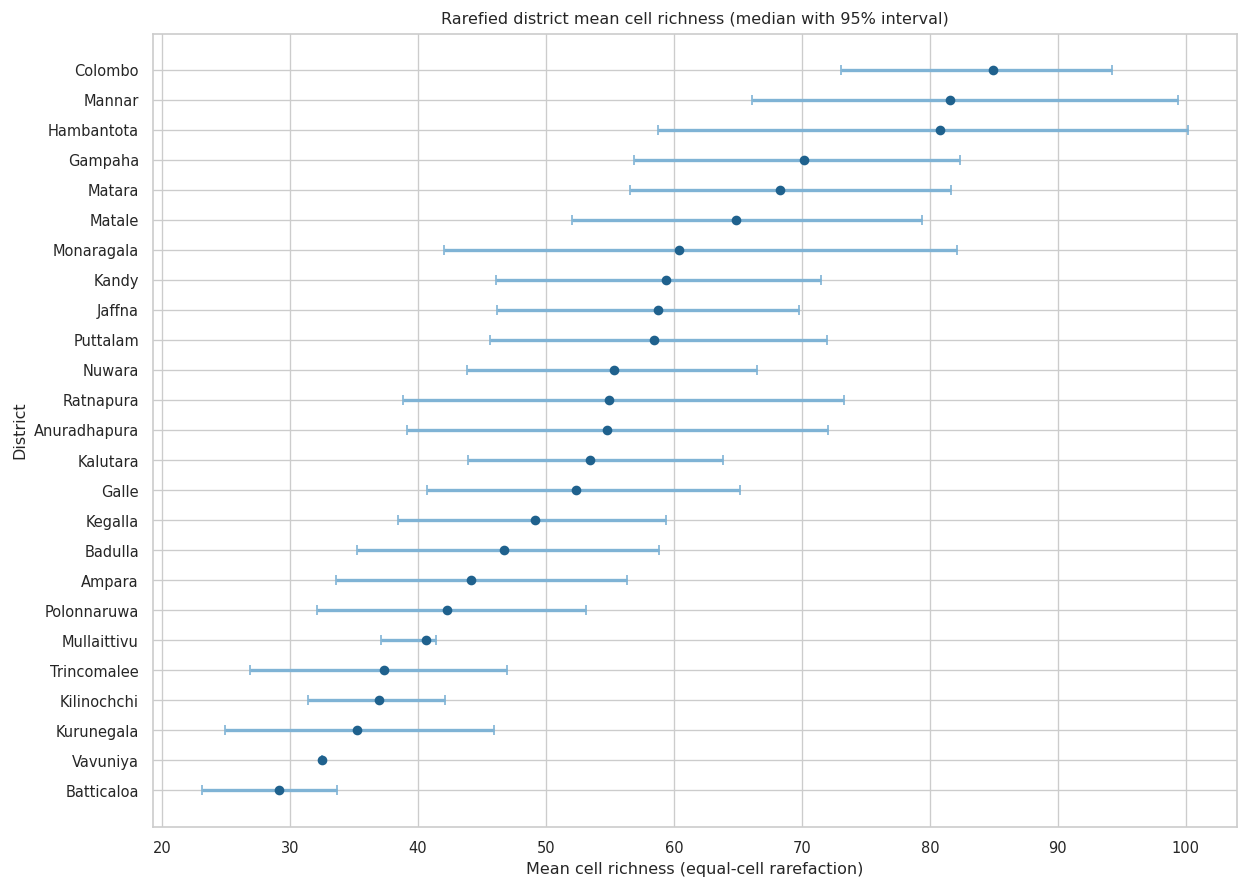

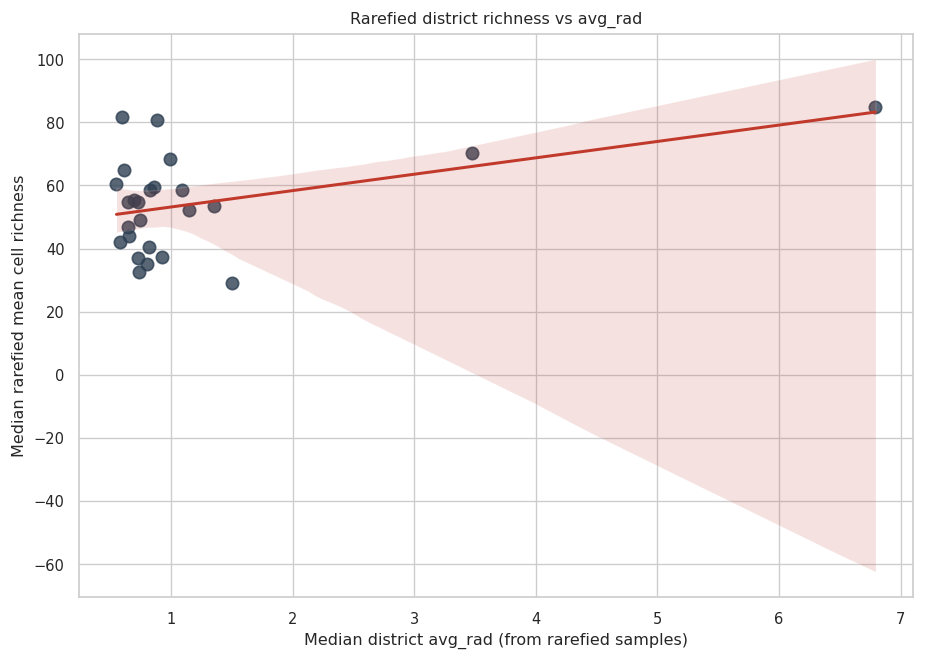

In [35]:
# Rarefaction visualizations
rs = rarefied_summary.sort_values("mean_cell_richness_median", ascending=True).copy()

x = rs["mean_cell_richness_median"].to_numpy()
xerr = np.vstack([
    x - rs["mean_cell_richness_q025"].to_numpy(),
    rs["mean_cell_richness_q975"].to_numpy() - x,
])

plt.figure(figsize=(10.5, max(5.5, 0.30 * len(rs))))
plt.errorbar(
    x,
    rs["stateProvince"],
    xerr=xerr,
    fmt="o",
    color="#1f618d",
    ecolor="#7fb3d5",
    elinewidth=2,
    capsize=3,
)
plt.title("Rarefied district mean cell richness (median with 95% interval)")
plt.xlabel("Mean cell richness (equal-cell rarefaction)")
plt.ylabel("District")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.8, 5.6))
sns.regplot(
    data=rarefied_summary,
    x="mean_avg_rad_median",
    y="mean_cell_richness_median",
    scatter_kws={"s": 55, "alpha": 0.8, "color": "#2e4053"},
    line_kws={"color": "#c0392b"},
)
plt.title("Rarefied district richness vs avg_rad")
plt.xlabel("Median district avg_rad (from rarefied samples)")
plt.ylabel("Median rarefied mean cell richness")
plt.tight_layout()
plt.show()